In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm
import glob

In [3]:
def get_k_modes():
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
    )
    mock.downres_factor_transverse = 3
    mock.downres_factor_radial = 6
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1
def bin_power_cy(
    power_3d,
    k_perp,
    k_para,
    kperpbins,
    kparabins,
    kweights=None,
):
    pcy_arr = bin_3d_to_cy(
        power_3d, k_perp, kperpbins, vectorize=True,
        weights=kweights,
    )
    pcy_arr = bin_3d_to_cy(
        np.nan_to_num(pcy_arr), np.abs(k_para), kparabins, vectorize=True,
        weights=(1-np.isnan(pcy_arr))[0].astype('float'),
    )
    return pcy_arr

def bin_power_1d(
    power_3d,
    k_mode,
    k1dbins,
    kweights,
    num_split=None,
):
    if num_split is None:
        p1d, keff, nmodes = bin_3d_to_1d(
            power_3d, k_mode, k1dbins, vectorize=True,weights=kweights,
        )
    else:
        p1d = []
        power_3d_arr = np.array_split(power_3d,num_split)
        for i in range(num_split):
            pdata1darr_i, keff, nmodes = bin_3d_to_1d(
                power_3d_arr[i], k_mode, k1dbins, vectorize=True,weights=kweights,
            )
            p1d.append(pdata1darr_i)
        p1d = np.concatenate(p1d)
    return p1d, keff, nmodes

In [4]:
kperp, kpara, kmode, kvec = get_k_modes()

In [5]:
file_arr = glob.glob('/users/ztchen/scratch3/validation/02/*[0-9]_cross.npz')

In [6]:
len(file_arr)

1000

In [7]:
phi3d_arr = []
phimod3d_arr = []
pg3d_arr = []
pgmod3d_arr = []
pcross3d_arr = []
pcrossmod3d_arr = []
phiclean3d_arr = []
pcrossclean3d_arr = []
power_tf_before = []
power_tf_after = []
for file in file_arr:
    data = np.load(file)
    phi3d_arr.append(data['phi3d_arr'])
    phimod3d_arr.append(data['phimod3d_arr'])
    pg3d_arr.append(data['pg3d_arr'])
    pgmod3d_arr.append(data['pgmod3d_arr'])
    pcross3d_arr.append(data['pcross3d_arr'])
    pcrossmod3d_arr.append(data['pcrossmod3d_arr'])
    phiclean3d_arr.append(data['phiclean3d_arr'])
    pcrossclean3d_arr.append(data['pcrossclean3d_arr'])
    power_tf_before.append(data['power_tf_before'])
    power_tf_after.append(data['power_tf_after'])

In [8]:
phi3d_arr = np.array(phi3d_arr)
phimod3d_arr = np.array(phimod3d_arr)[0]
pg3d_arr = np.array(pg3d_arr)
pgmod3d_arr = np.array(pgmod3d_arr)[0]
pcross3d_arr = np.array(pcross3d_arr)
pcrossmod3d_arr = np.array(pcrossmod3d_arr)[0]
phiclean3d_arr = np.array(phiclean3d_arr)
pcrossclean3d_arr = np.array(pcrossclean3d_arr)
power_tf_before = np.array(power_tf_before)
power_tf_after = np.array(power_tf_after)

In [9]:
k_xy_sel = (
    (np.abs(kvec[0])<0.016)[:,None,None] 
    * (np.abs(kvec[1])<0.016)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [9]:
phicy_arr = bin_power_cy(
    phi3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
phimodcy_arr = bin_power_cy(
    phimod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]


pgcy_arr = bin_power_cy(
    pg3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pgmodelcy_arr = bin_power_cy(
    pgmod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]



pxcy_arr = bin_power_cy(
    pcross3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pxmodelcy_arr = bin_power_cy(
    pcrossmod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

phicleancy_arr = bin_power_cy(
    phiclean3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)

pxcleancy_arr = bin_power_cy(
    pcrossclean3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)

/users/ztchen/meer21cm/src/meer21cm/power.py:2045: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


Text(0.5, 0.98, 'HI Auto, mock + model + ratio')

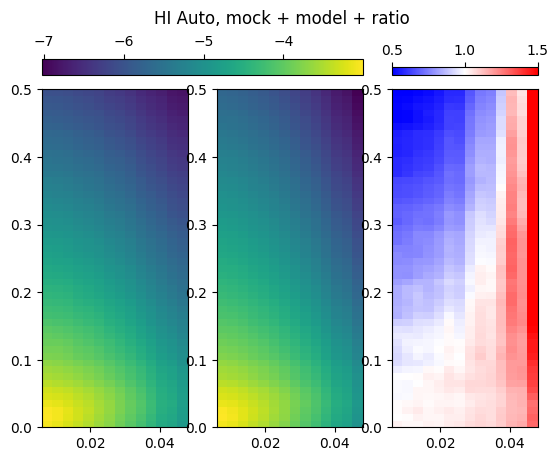

In [10]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    phicy_arr,
    phimodcy_arr,
    0.5,
    1.5,
)
fig.suptitle('HI Auto, mock + model + ratio')

Text(0.5, 0.98, 'HI Auto , mock + cleaned + ratio')

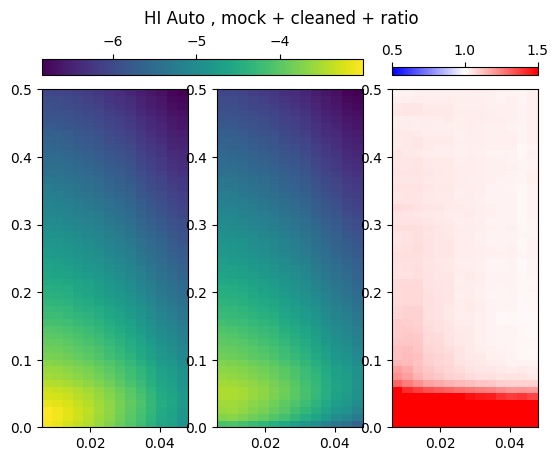

In [11]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    phicy_arr,
    phicleancy_arr[0],
    0.5,
    1.5,
)
fig.suptitle('HI Auto , mock + cleaned + ratio')

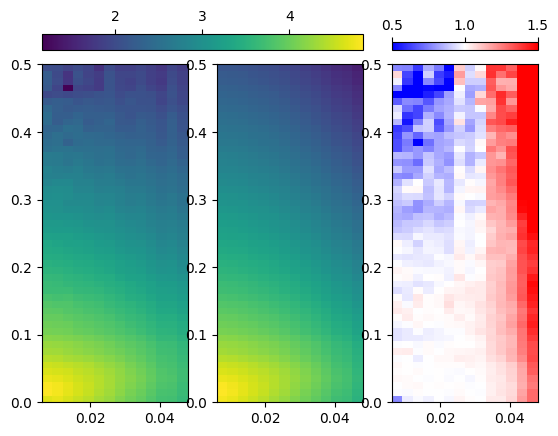

In [12]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pgcy_arr,
    pgmodelcy_arr,
    0.5,
    1.5,
)

Text(0.5, 0.98, 'Cross, mock + model + ratio')

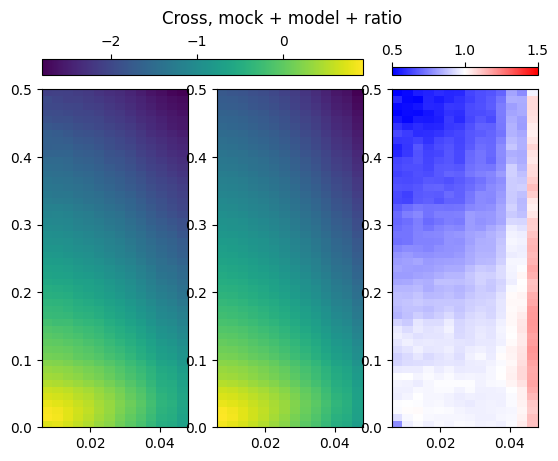

In [13]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr,
    pxmodelcy_arr,
    0.5,
    1.5,
)
fig.suptitle('Cross, mock + model + ratio')

Text(0.5, 0.98, 'Cross, mock + cleaned + ratio')

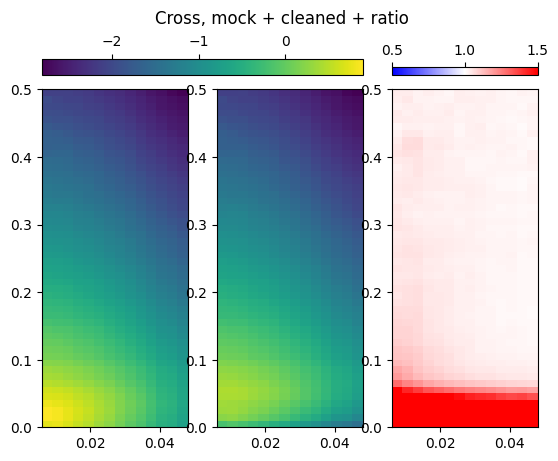

In [14]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr,
    pxcleancy_arr[0],
    0.5,
    1.5,
)
fig.suptitle('Cross, mock + cleaned + ratio')

In [15]:
phi1darr, keff, nmodes = bin_power_1d(
    phi3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pmod1darr, keff, nmodes = bin_power_1d(
    phimod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pmod1darr = pmod1darr[0]

pg1darr, keff, nmodes = bin_power_1d(
    pg3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pgmod1darr, keff, nmodes = bin_power_1d(
    pgmod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pgmod1darr = pgmod1darr[0]

px1darr, keff, nmodes = bin_power_1d(
    pcross3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pxmod1darr, keff, nmodes = bin_power_1d(
    pcrossmod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pxmod1darr = pxmod1darr[0]

ptfbefore1darr,_,_ = bin_power_1d(
    power_tf_before,
    kmode,
    k1dbins,
    k_xy_sel,
)
ptfafter1darr,_,_ = bin_power_1d(
    power_tf_after,
    kmode,
    k1dbins,
    k_xy_sel,
)
phiclean1darr,_,_ = bin_power_1d(
    phiclean3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
)
pxclean1darr,_,_ = bin_power_1d(
    pcrossclean3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
)

In [16]:
tf3d = power_tf_after.mean(0)/power_tf_before.mean(0)

In [31]:
phimodclean1darr,_,_ = bin_power_1d(
    (phimod3d_arr*tf3d)[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pxmodclean1darr,_,_ = bin_power_1d(
    (pcrossmod3d_arr*tf3d)[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pxmodelcleancy_arr = bin_power_cy(
    (pcrossmod3d_arr*tf3d)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]
phimodelcleancy_arr = bin_power_cy(
    (phimod3d_arr*tf3d)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

Text(0.5, 0.98, 'Cross, mock cleaned + model TF corrected + ratio')

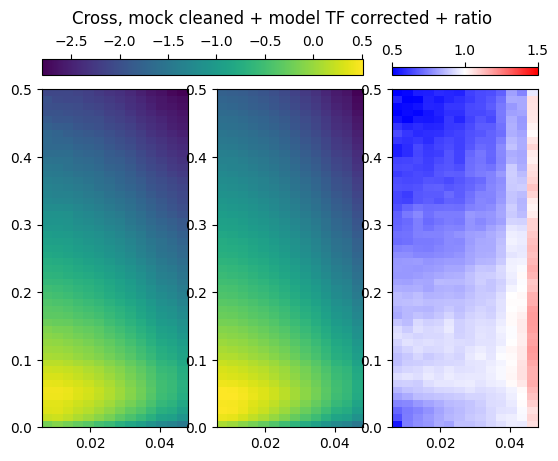

In [34]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcleancy_arr,
    pxmodelcleancy_arr,
    0.5,
    1.5,
)
fig.suptitle('Cross, mock cleaned + model TF corrected + ratio')

In [26]:
tf_1d = ptfbefore1darr.mean(0)/ptfafter1darr.mean(0)

/users/ztchen/meer21cm/papers/validation/specs.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


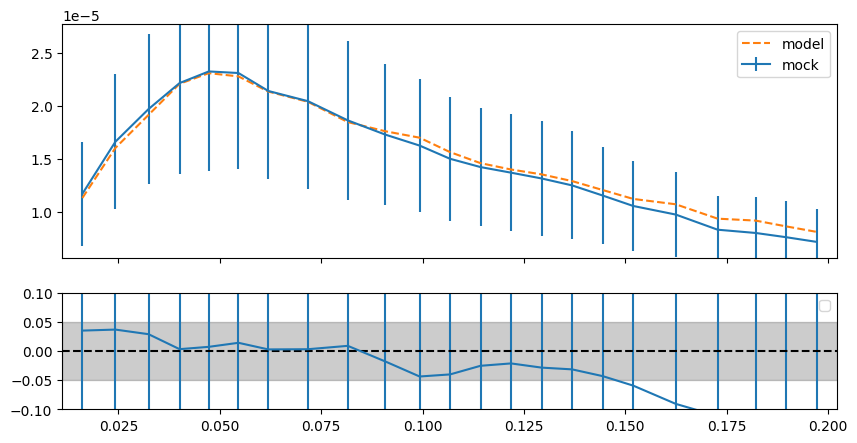

In [25]:
plot_1d_power(
        keff,
        phi1darr,
        pmod1darr,
        -0.1,
        0.1,
    );

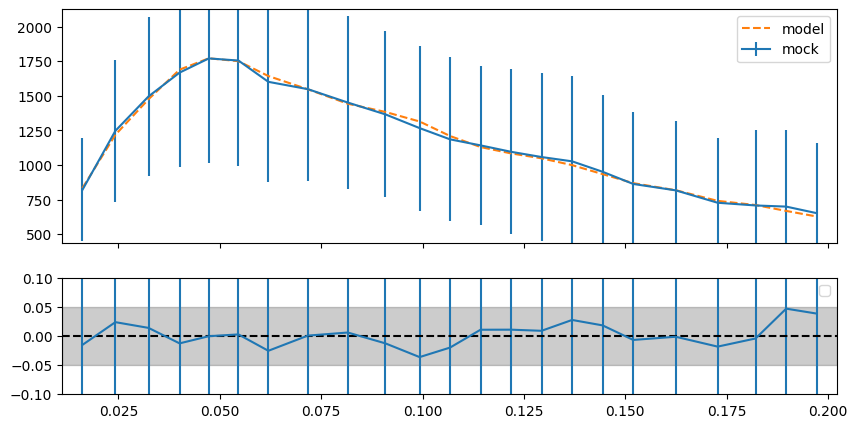

In [26]:
plot_1d_power(
        keff,
        pg1darr,
        pgmod1darr,
        -0.1,
        0.1,
    );

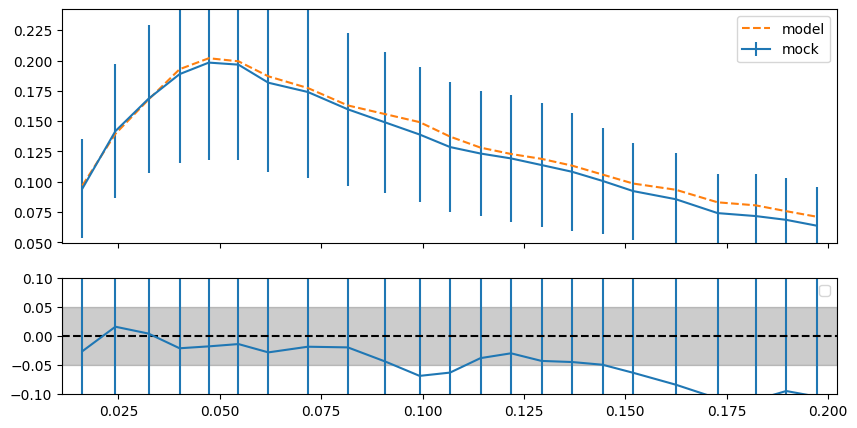

In [27]:
plot_1d_power(
        keff,
        px1darr,
        pxmod1darr,
        -0.1,
        0.1,
    );

/users/ztchen/meer21cm/papers/validation/specs.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


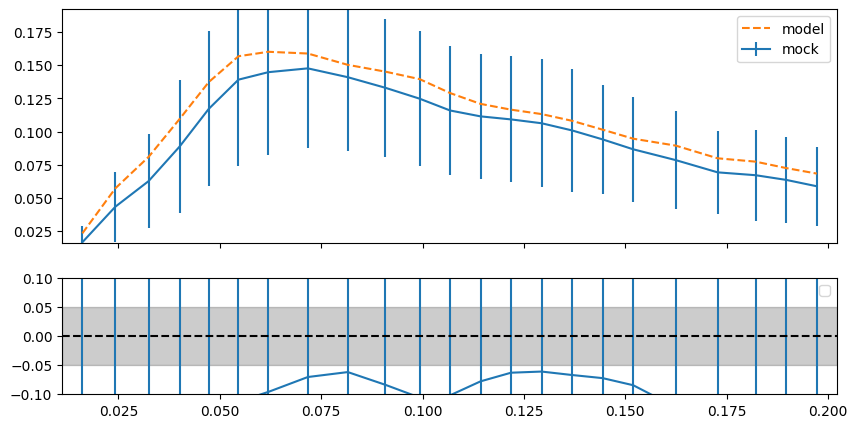

In [27]:
plot_1d_power(
        keff,
        pxclean1darr,
        pxmod1darr/tf_1d,
        -0.1,
        0.1,
    );

In [10]:
k_tf_sel = (
    (np.abs(kvec[0])<0.016)[:,None,None]
    * (np.abs(kvec[0])>0.004)[:,None,None]
    * (np.abs(kvec[1])<0.016)[None,:,None]
    * (np.abs(kvec[1])>0.004)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
    * (np.abs(kvec[2])>0.02)[None,None,:]
)

In [15]:
pxclean1darr_sel,_,_ = bin_power_1d(
    pcrossclean3d_arr,
    kmode,
    k1dbins,
    k_tf_sel,
    num_split=20,
)
#pxmod1darr_seltf,_,_ = bin_power_1d(
#    (pcrossmod3d_arr*tf3d)[None],
#    kmode,
#    k1dbins,
#    k_tf_sel,
#)
#pxmod1darr_seltf = pxmod1darr_seltf[0]

In [16]:
px1darr_sel,keff_sel,_ = bin_power_1d(
    pcross3d_arr,
    kmode,
    k1dbins,
    k_tf_sel,
    num_split=20,
)
pxmod1darr_sel,_,_ = bin_power_1d(
    (pcrossmod3d_arr)[None],
    kmode,
    k1dbins,
    k_tf_sel,
)
pxmod1darr_sel = pxmod1darr_sel[0]

In [12]:
phi1darr_sel,_,_ = bin_power_1d(
    phi3d_arr,
    kmode,
    k1dbins,
    k_tf_sel,
    num_split=20,
)
phiclean1darr_sel,_,_ = bin_power_1d(
    phiclean3d_arr,
    kmode,
    k1dbins,
    k_tf_sel,
    num_split=20,
)
phimod1darr_sel,_,_ = bin_power_1d(
    (phimod3d_arr)[None],
    kmode,
    k1dbins,
    k_tf_sel,
)
phimod1darr_sel = phimod1darr_sel[0]

In [17]:
phimod3d_arr.shape

(11, 35, 87)

In [33]:
Hab = np.load('Hab.npy')
phimod1darr_hab,k_hab,_ = bin_power_1d(
    np.einsum(
        'ij,abj->abi',
        Hab,
        phimod3d_arr,
    )[None],
    kmode,
    k1dbins,
    #k_tf_sel,
    k_cy_sel,
)
pxmod1darr_hab,k_hab,_ = bin_power_1d(
    #np.einsum(
    #    'ij,abj->abi',
    #    Hab,
    #    pcrossmod3d_arr,
    #)[None],
    pcrossmod3d_arr * Hab.sum(1)[None,None,:],
    kmode,
    k1dbins,
    #k_tf_sel,
    k_cy_sel,
)

pxclean1darr_hab,_,_ = bin_power_1d(
    pcrossclean3d_arr,
    kmode,
    k1dbins,
    k_cy_sel,
    num_split=20,
)
phiclean1darr_hab,_,_ = bin_power_1d(
    phiclean3d_arr,
    kmode,
    k1dbins,
    k_cy_sel,
    num_split=20,
)

px1darr_hab,_,_ = bin_power_1d(
    pcross3d_arr,
    kmode,
    k1dbins,
    k_cy_sel,
    num_split=20,
)
phi1darr_hab,_,_ = bin_power_1d(
    phi3d_arr,
    kmode,
    k1dbins,
    k_cy_sel,
    num_split=20,
)

In [20]:
tf1darr_sel = pxclean1darr_sel.mean(0)/px1darr_sel.mean(0)

In [21]:
def plot_1d_power(
    keff,
    pdatad,
    pmodd,
    ratio_min,
    ratio_max,
):
    keff = np.array(keff)
    pdatad = np.array(pdatad)
    pmodd = np.array(pmodd)
    sel = keff == keff
    keff = keff[sel]
    pdatad = pdatad[:, sel]
    pmodd = pmodd[sel]
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 5),
        sharex=True,
        height_ratios=[2, 1],
    )
    axes[0].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff,
        label="mock",
    )
    axes[0].plot(keff, pmodd * keff, label="model", ls="--")
    axes[0].set_ylim(
        np.nanmin(pmodd * keff) * 0.7, 
        np.nanmax(pmodd * keff) * 1.2
    )
    axes[0].legend()
    axes[1].errorbar(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[1].axhline(0, color="black", ls="--")
    axes[1].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[1].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[1].set_ylim(ratio_min, ratio_max)
    axes[1].legend()
    return fig

/tmp/ipykernel_3101741/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


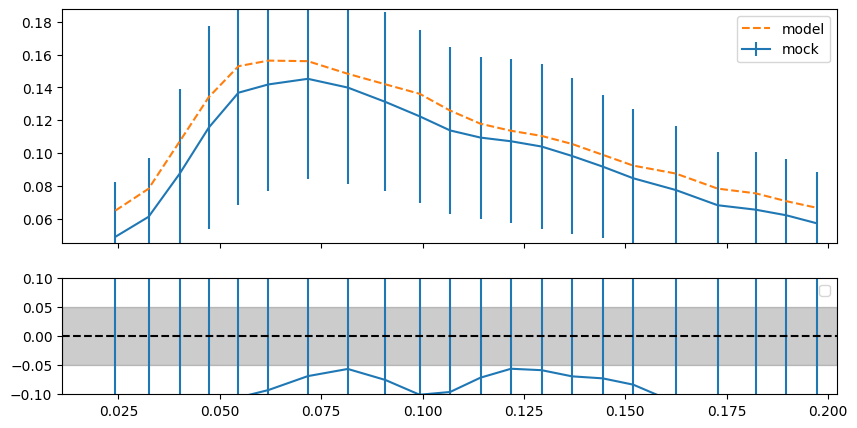

In [50]:
plot_1d_power(
        keff,
        pxclean1darr_sel,
        pxmod1darr_seltf,
        -0.1,
        0.1,
    );

/tmp/ipykernel_3101741/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


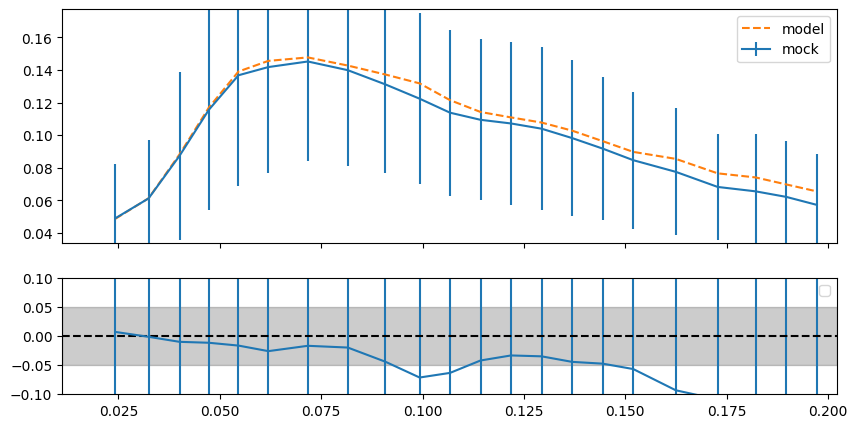

In [51]:
plot_1d_power(
        keff,
        pxclean1darr_sel,
        pxmod1darr_sel*tf1darr_sel,
        -0.1,
        0.1,
    );

/tmp/ipykernel_2765174/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


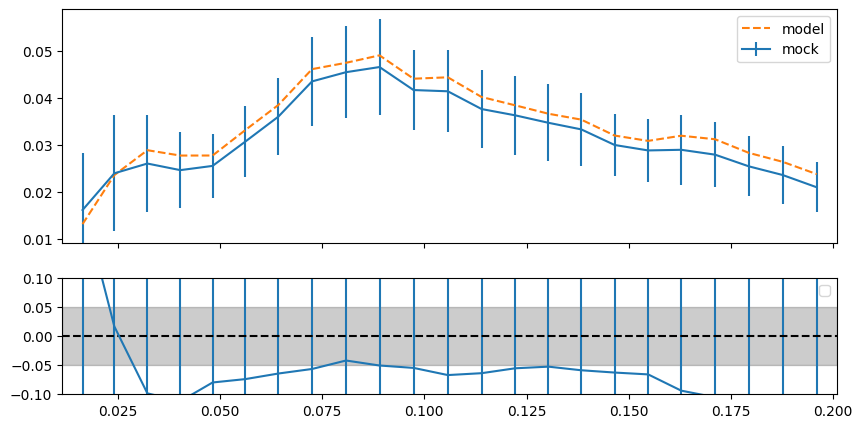

In [35]:
plot_1d_power(
        k_hab,
        pxclean1darr_hab,
        pxmod1darr_hab[0],
        -0.1,
        0.1,
    );

/tmp/ipykernel_2765174/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


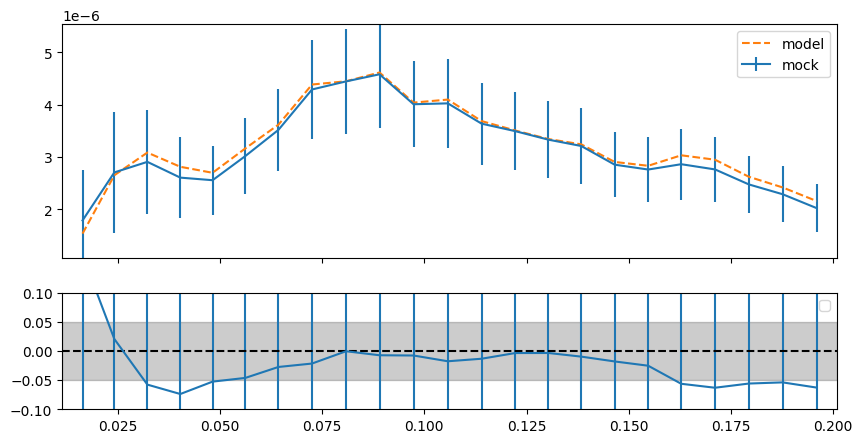

In [36]:
plot_1d_power(
        k_hab,
        phiclean1darr_hab,
        phimod1darr_hab[0],
        -0.1,
        0.1,
    );

/tmp/ipykernel_2765174/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


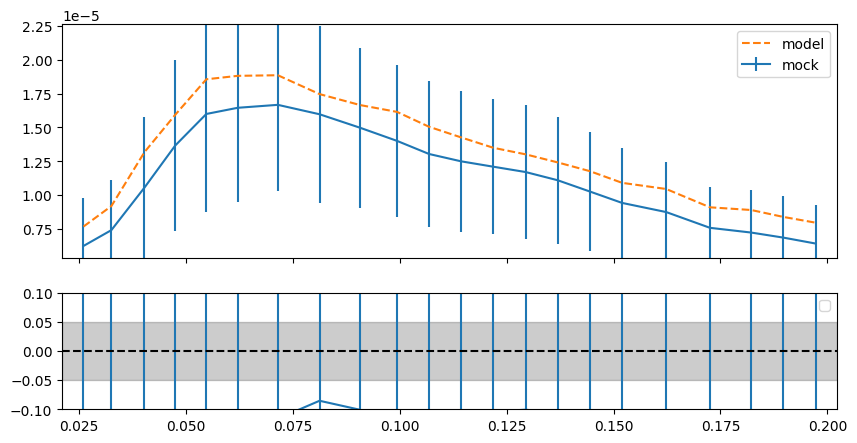

In [31]:
plot_1d_power(
        keff_sel,
        phiclean1darr_sel,
        phimod1darr_hab[0],
        -0.1,
        0.1,
    );

/tmp/ipykernel_3101741/2408993318.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


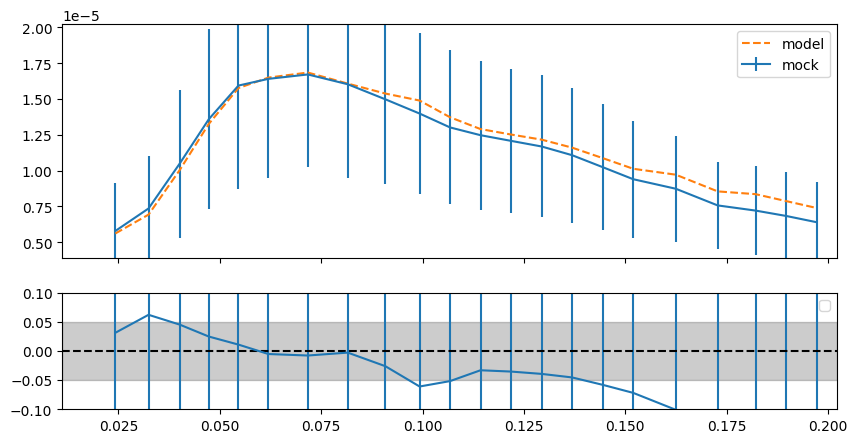

In [55]:
plot_1d_power(
        keff,
        phiclean1darr_sel,
        phimod1darr_sel*tf1darr_sel,
        -0.1,
        0.1,
    );

In [38]:
arr.shape

(2, 50, 14)

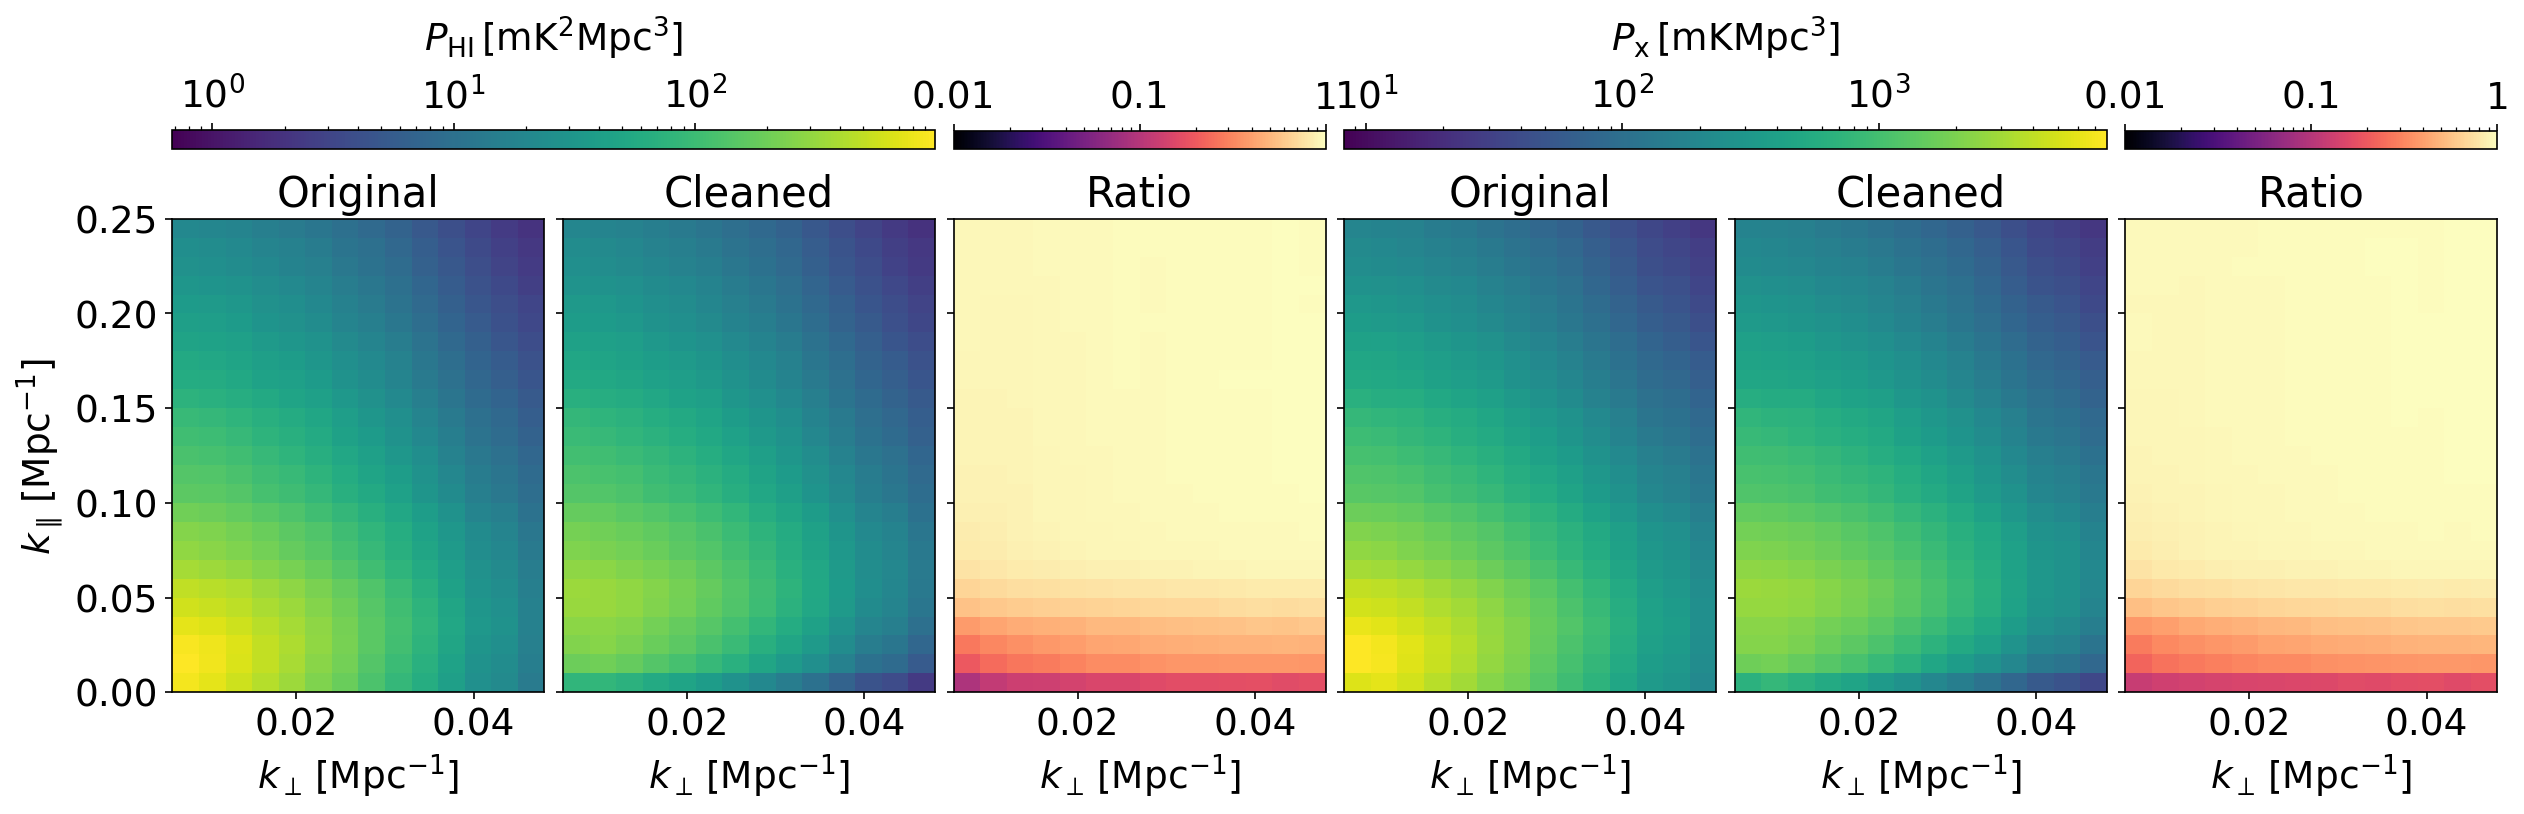

In [42]:
plt.rcParams['font.size'] = 18
fig, axes = plt.subplots(1, 6,figsize=(20,5),gridspec_kw={'wspace':0.05},dpi=150)
pmockarr = [phicy_arr*1e6,pxcy_arr*1e3]
pmodelarr = [phicleancy_arr*1e6,pxcleancy_arr*1e3]
ylabelarr= [
    r'$P_{\rm HI}\,[{\rm mK^2 Mpc^3}]$',
    r'$P_{\rm x}\,[{\rm mK Mpc^3}]$',
]
for ax in axes:
    ax.set_ylim(0,0.25)
for i in range(2):
    xbins = kperpbins
    ybins = kparabins
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy.mean(axis=0).T),
        (pmodcy.mean(axis=0).T),
    ])
    vmin = np.nanmin(arr[:,:35])
    if vmin<0:
        vmin = 1
    vmax = np.nanmax(arr[:,:35])
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        arr[0],
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[0+i*3].set_title('Original',fontsize=20)
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[{\rm Mpc^{-1}}]$')
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        arr[1],
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    axes[1+i*3].set_title('Cleaned',fontsize=20)
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.12,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        arr[1]/arr[0],
        #vmin=vmin_ratio,
        #vmax=vmax_ratio,
        norm=LogNorm(vmin=1e-2, vmax=1),
        cmap="magma",
    )
    axes[2+i*3].set_yticklabels([])
    axes[2+i*3].set_title('Ratio',fontsize=20)
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.12)
    cbar.set_ticks([0.01,0.1,1])
    cbar.set_ticklabels(['0.01', '0.1', '1'])
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[{\rm Mpc^{-1}}]$')
plt.savefig('plots/02_cy.pdf',dpi=150, bbox_inches = "tight")

In [23]:
keff_sel = keff_sel[1:]

In [ ]:
plt.rcParams['font.size'] = 20
fig,axes=plt.subplots(
    3,2,figsize=(27,5),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [phi1darr_sel[:,1:]*1e6,px1darr_sel[:,1:]*1e3]
pcleanarr = [phiclean1darr_sel[:,1:]*1e6,pxclean1darr_sel[:,1:]*1e3]
pmodelarr = [
    (phimod1darr_sel*tf1darr_sel)[1:]*1e6,
    (pxmod1darr_sel*tf1darr_sel)[1:]*1e3]
titlearr = [r'HI power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[{\rm mK Mpc^2}]$',
]
for i in range(2):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    pcleand = pcleanarr[i]
    axes[0,i].errorbar(
        keff_sel-0.0005,
        pdatad.mean(axis=0) * keff_sel,
        yerr=pdatad.std(axis=0) * keff_sel / np.sqrt(10),
        ls='None',
        marker='s',
        label="Original mock",
        elinewidth=2,
    )
    axes[0,i].errorbar(
        keff_sel+0.0005,
        pcleand.mean(axis=0) * keff_sel,
        yerr=pcleand.std(axis=0) * keff_sel / np.sqrt(10),
        ls='None',
        marker='^',
        label="Cleaned mock",
        elinewidth=2,
    )
    axes[0,i].plot(keff_sel, pmodd * keff_sel, label="TF corrected model", ls="--",lw=2)
    axes[0,i].set_ylim((pmodd * keff_sel).min() * 0.5, (pmodd * keff_sel).max() * 1.5)
    #axes[0,i].legend()
    #axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    #axes[0,i].set_title(titlearr[i])
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        keff_sel,
        (pcleand.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(10),
        lw=3,
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)
    axes[2,i].plot(
        keff_sel,
        (pcleand.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    #axes[2,i].set_yscale('symlog',linthresh=0.05)
    #axes[2,i].set_yticks([-0.15,-0.05,0,0.05,0.15])
    #axes[2,i].set_yticklabels(['-0.15','-0.05','','0.05','0.15'])
    #axes[2,i].legend()
    axes[2,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
    if i == 1:
        axes[0,i].legend(loc='upper left', bbox_to_anchor=[0.63,1.4])
        
plt.savefig('plots/02_1d.pdf',dpi=150, bbox_inches = "tight")

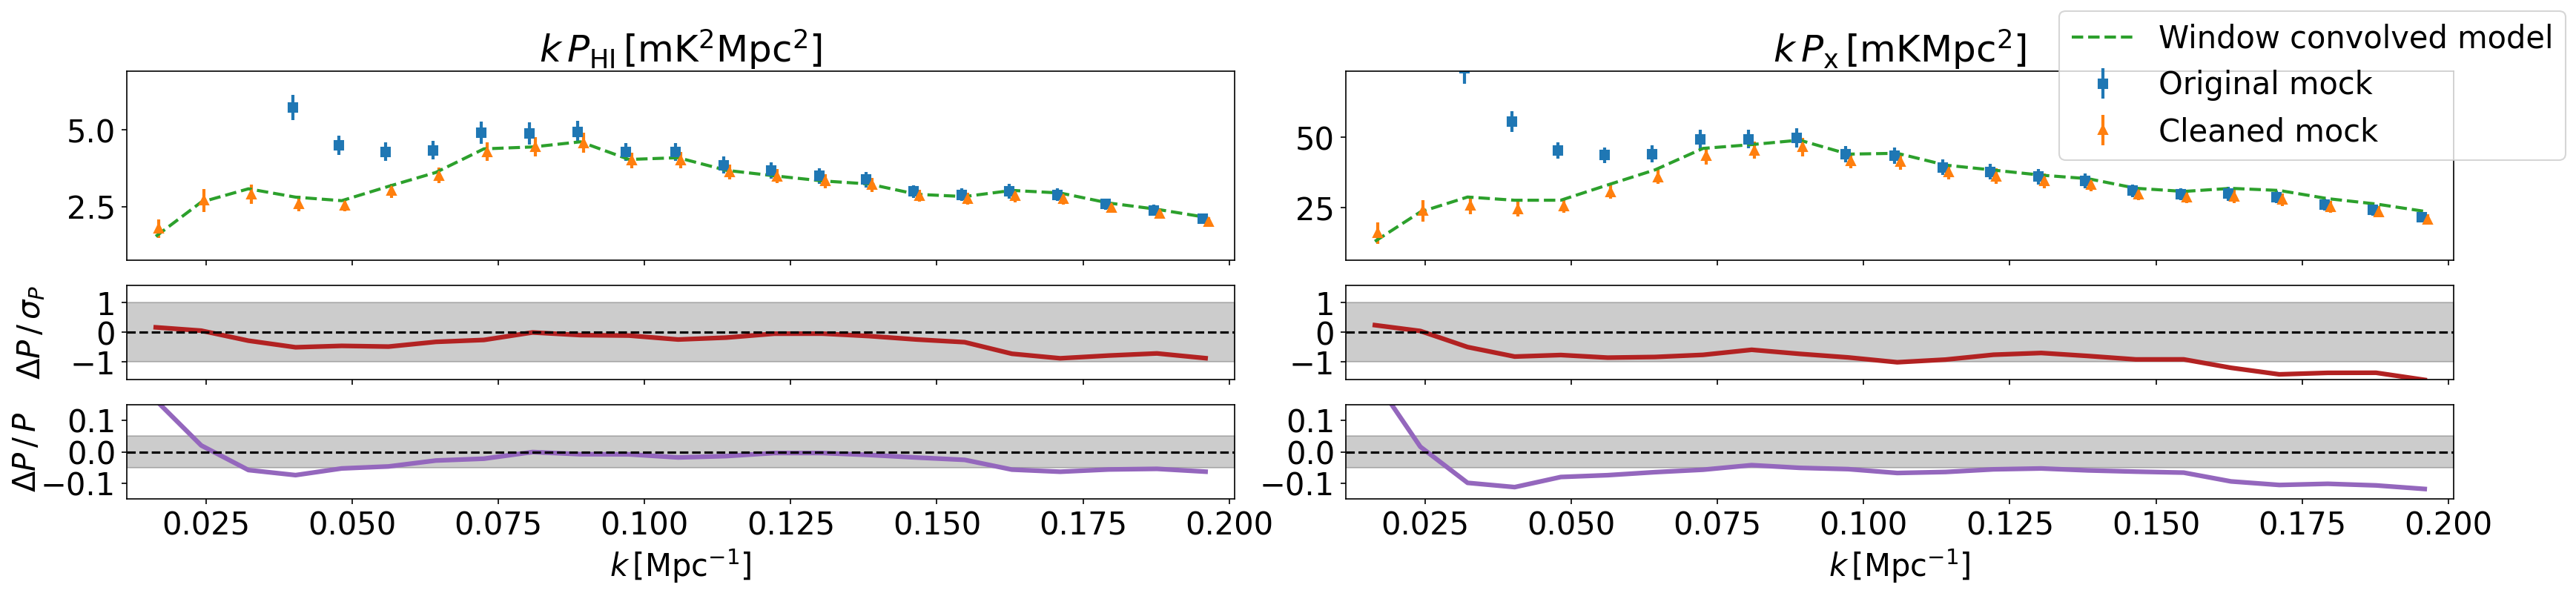

In [43]:
plt.rcParams['font.size'] = 20
fig,axes=plt.subplots(
    3,2,figsize=(27,5),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [phi1darr_hab[:,:]*1e6,px1darr_hab[:,:]*1e3]
pcleanarr = [phiclean1darr_hab[:,:]*1e6,pxclean1darr_hab[:,:]*1e3]
pmodelarr = [
    phimod1darr_hab[0]*1e6,
    pxmod1darr_hab[0]*1e3]
titlearr = [r'HI power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[{\rm mK Mpc^2}]$',
]
for i in range(2):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    pcleand = pcleanarr[i]
    axes[0,i].errorbar(
        k_hab-0.0005,
        pdatad.mean(axis=0) * k_hab,
        yerr=pdatad.std(axis=0) * k_hab / np.sqrt(10),
        ls='None',
        marker='s',
        label="Original mock",
        elinewidth=2,
    )
    axes[0,i].errorbar(
        k_hab+0.0005,
        pcleand.mean(axis=0) * k_hab,
        yerr=pcleand.std(axis=0) * k_hab / np.sqrt(10),
        ls='None',
        marker='^',
        label="Cleaned mock",
        elinewidth=2,
    )
    axes[0,i].plot(k_hab, pmodd * k_hab, label="Window convolved model", ls="--",lw=2)
    axes[0,i].set_ylim((pmodd * k_hab).min() * 0.5, (pmodd * k_hab).max() * 1.5)
    #axes[0,i].legend()
    #axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    #axes[0,i].set_title(titlearr[i])
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        k_hab,
        (pcleand.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(10),
        lw=3,
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].fill_between(
        np.linspace(k_hab.min() - 0.005, k_hab.max() + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    axes[1,i].set_xlim(k_hab.min()-0.005,k_hab.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)
    axes[2,i].plot(
        k_hab,
        (pcleand.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(k_hab.min() - 0.005, k_hab.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(k_hab.min() - 0.005, k_hab.max() + 0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    #axes[2,i].set_yscale('symlog',linthresh=0.05)
    #axes[2,i].set_yticks([-0.15,-0.05,0,0.05,0.15])
    #axes[2,i].set_yticklabels(['-0.15','-0.05','','0.05','0.15'])
    #axes[2,i].legend()
    axes[2,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
    if i == 1:
        axes[0,i].legend(loc='upper left', bbox_to_anchor=[0.63,1.4])
        
plt.savefig('plots/02_1d_hab.pdf',dpi=150, bbox_inches = "tight")